<a href="https://colab.research.google.com/github/Priti-Kannaujiya/DeepLearning-FromScratch/blob/main/CNN_LSTM(Sentiment_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [ ]:
import os
os.listdir(path)

['IMDB Dataset.csv']

In [ ]:
import pandas as pd
df = pd.read_csv(path + "/IMDB Dataset.csv")
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [ ]:
!pip install nltk

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)     # remove html
    text = re.sub(r'http\S+', '', text)   # remove url
    text = re.sub(r'[^a-zA-Z]', ' ', text) # remove special char

    words = text.split()

    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [ ]:
df['clean_review'] = df['review'].apply(preprocess)

In [ ]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visually stunnin...


In [ ]:
df.drop('review', axis=1, inplace=True)

In [ ]:
df.shape

(50000, 2)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
texts = df['clean_review']
tokenizer = Tokenizer(num_words=20000)       # we are taking top 10000 words that are appearing frequently
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

In [ ]:
len(tokenizer.word_index)

91710

In [ ]:
sequences

[[3,
  1037,
  921,
  64,
  2814,
  168,
  2910,
  100,
  502,
  474,
  22,
  25,
  2944,
  2814,
  4814,
  13299,
  16,
  448,
  111,
  100,
  243,
  30,
  1524,
  23,
  6043,
  2120,
  10211,
  23,
  906,
  1937,
  2046,
  575,
  260,
  448,
  3470,
  216,
  253,
  243,
  323,
  2814,
  9189,
  254,
  13063,
  6158,
  2335,
  570,
  747,
  1250,
  19582,
  380,
  4237,
  1916,
  1003,
  1904,
  1790,
  792,
  219,
  14675,
  193,
  3991,
  2653,
  380,
  232,
  37,
  12172,
  3710,
  10912,
  6375,
  1149,
  830,
  2233,
  19583,
  197,
  3815,
  6531,
  1621,
  7775,
  7370,
  42,
  126,
  142,
  11,
  40,
  179,
  1053,
  23,
  552,
  88,
  30,
  23,
  2446,
  682,
  91,
  236,
  3764,
  2282,
  153,
  682,
  1132,
  682,
  680,
  2814,
  778,
  94,
  22,
  168,
  47,
  114,
  2944,
  1447,
  2038,
  40,
  1415,
  187,
  1254,
  946,
  2814,
  99,
  9090,
  193,
  400,
  1234,
  448,
  448,
  5743,
  6425,
  1884,
  2721,
  18361,
  4791,
  263,
  443,
  10,
  142,
  15,
  6814,
  

In [ ]:
max_len = 300
sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

In [ ]:
sequences

array([[   3, 1037,  921, ...,    0,    0,    0],
       [ 285,   46,  222, ...,    0,    0,    0],
       [  87,  285,   24, ...,    0,    0,    0],
       ...,
       [2883, 3955, 7400, ...,    0,    0,    0],
       [  76, 2752,  777, ...,    0,    0,    0],
       [   3, 5313,   92, ...,    0,    0,    0]], dtype=int32)

In [ ]:
sequences.shape

(50000, 300)

In [ ]:
y = df['sentiment']

In [ ]:
len(tokenizer.word_index)

91710

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    sequences, y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(Embedding(input_dim=25000, output_dim=128, input_shape=(300,)))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(64))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 300, 128)       │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 298, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 149, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,261,889 (12.44 MB)

 Trainable params: 3,261,889 (12.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.5103 - loss: 0.6926 - val_accuracy: 0.5885 - val_loss: 0.6484
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6633 - loss: 0.6022 - val_accuracy: 0.8564 - val_loss: 0.3327
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8938 - loss: 0.2759 - val_accuracy: 0.8817 - val_loss: 0.2798
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9406 - loss: 0.1705 - val_accuracy: 0.8935 - val_loss: 0.2625
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9695 - loss: 0.0997 - val_accuracy: 0.8854 - val_loss: 0.3003


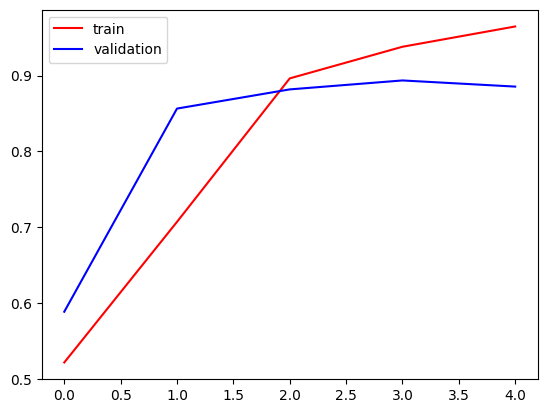

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
y_pred = (y_pred > 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8854
Precision: 0.9093585699263933
Recall: 0.8581067672157174
F1 Score: 0.882989585460486


# Prediction on text

In [ ]:
review1 = "Worst movie ever, waste of time"

In [ ]:
review1 = preprocess(review1)
review1

'worst movie ever waste time'

In [ ]:
seq = tokenizer.texts_to_sequences([review1])
padded = pad_sequences(seq, maxlen=300)
pred = model.predict(padded)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


array([[0.00739987]], dtype=float32)

In [ ]:
print("Prediction Score:", pred[0][0])

if pred[0][0] > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

Prediction Score: 0.007399868
Negative Review
